# Connor Maul, EID CSM3665

# Section 1: Introduction and Model Selection
For my real world system, I have chosen to model the population of Wolves in Yellowstone National Park upon their reintroduction in 1995. The governing second-oder ODE is option D, population dynamics, modeled by $\frac{d^2P}{dt^2} = rP - kP^2$. The system of first order ODEs is $y_1 = P$ and $y_2 = \frac{dP}{dt}$, with resulting system $\frac{dy_1}{dt} = y_2$ and $\frac{dy_2}{dt} = ry_1 - ky_1^2$. $r$ is the growth rate, $P$ is the population, $k$ is the carrying capacity ractor, calulated through $k = \frac{r}{P_{max}}$, where $P_{max}$ is the population carrying capacity. There are paramaters $y_1(0)$, which is the initial population, and $y_2(0)$, which is the initial growth rate.

# Section 2: Parameter Research & Justification

| Parameter | Symbol | Value | Units | Justification / Source |
| :--- | :--- | :--- | :--- | :--- |
| **Growth Rate** | $r$ | 0.10 | $1/year$ | [Average 10% annual growth](https://www.nps.gov/yell/learn/nature/upload/FINAL-FOR-APPROVAL-WOLF-REPORT-2020_508R.pdf) observed between 1995–2003. |
| **Carrying Capacity** | $P_{max}$ | 100 | Wolves | The population [stabilized at roughly 100 individuals](https://greateryellowstone.org/yellowstone-wolf-reintroduction) after the initial peak. |
| **Capacity Factor** | $k$ | 0.001 | $1/(wolf \cdot year)$ | Calculated via $k = \frac{r}{P_{max}}$ to ensure growth levels off at 100 wolves. |
| **Initial Population** | $y_1(0)$ | 14 | Wolves | The [number of wolves released](https://greateryellowstone.org/yellowstone-wolf-reintroduction#:~:text=Since%20the%20reintroduction%2C%20the%20wolves,throughout%20the%20Greater%20Yellowstone%20Ecosystem.) in the 1995 reintroduction group. |
| **Initial Growth Rate** | $y_2(0)$ | 1.4 | Wolves/year | Estimated initial velocity based on the starting population and growth rate ($r \cdot y_1$). |

**Physical Scenario:** This model simulates the reintroduction of Gray Wolves into Yellowstone National Park. After being absent for decades, a small initial group was released in 1995. The second-order dynamics account for the acceleration of the population as they utilized the abundant elk herds, eventually slowing down as they reached the park's carrying capacity.

In [1]:
import numpy as np
def wolf_dynamics(t, y, r, k):
    y1, y2 = y
    dy1_dt = y2
    dy2_dt = r * y1 - k * y1**2
    return [dy1_dt, dy2_dt]

# Function for Euler's forward method
def euler_method(f, y0, t0, tf, h, args=()):
    """
    Solves a system of ODEs using Euler's Forward Method.
    
    Parameters:
        f: The derivative function (model)
        y0: List of initial conditions [y1, y2]
        t0: Start time
        tf: End time
        h: Step size
        args: Extra arguments for the model (r, k)
    """
    t_values = np.arange(t0, tf + h, h)
    # Initialize a 2D array: rows = time steps, columns = [y1, y2]
    y_values = np.zeros((len(t_values), len(y0)))
    
    y_values[0] = y0 # Initial population and initial growth rate
    
    for i in range(1, len(t_values)):
        t = t_values[i-1]
        y = y_values[i-1]
        
        # Calculate derivatives
        derivatives = f(t, y, *args)
        
        # Update step: y_new = y_old + h * dy/dt
        y_values[i] = y + h * np.array(derivatives)
        
    return t_values, y_values
    
# Function for the RK4 method
def runge_kutta_4(f, y0, t0, tf, h, args=()):
    """
    Solves a system of ODEs using the 4th Order Runge-Kutta Method.
    """
    t_values = np.arange(t0, tf + h, h)
    # Initialize 2D array for [population, growth_rate]
    y_values = np.zeros((len(t_values), len(y0)))
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        t = t_values[i-1]
        y = y_values[i-1]
        
        # Calculate the four RK4 slopes
        # Note: np.array() ensures vector addition works correctly
        k1 = np.array(f(t, y, *args))
        k2 = np.array(f(t + h/2, y + h*k1/2, *args))
        k3 = np.array(f(t + h/2, y + h*k2/2, *args))
        k4 = np.array(f(t + h, y + h*k3, *args))
        
        # Combined weighted update
        y_values[i] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        
    return t_values, y_values

# Section 3: Numerical Methods Implementation
For Euler's Method and RK4, I took the algorithms used in previous challenges and homeworks and converted them to run on 2D arrays, since it is not a system of first order ODEs instead of a singular ODE. This allows the functions to track both population ($y_1$) and growth rate ($y_2$).

/tmp/ipykernel_3426/2660756529.py:5: RuntimeWarning: overflow encountered in scalar power
  dy2_dt = r * y1 - k * y1**2


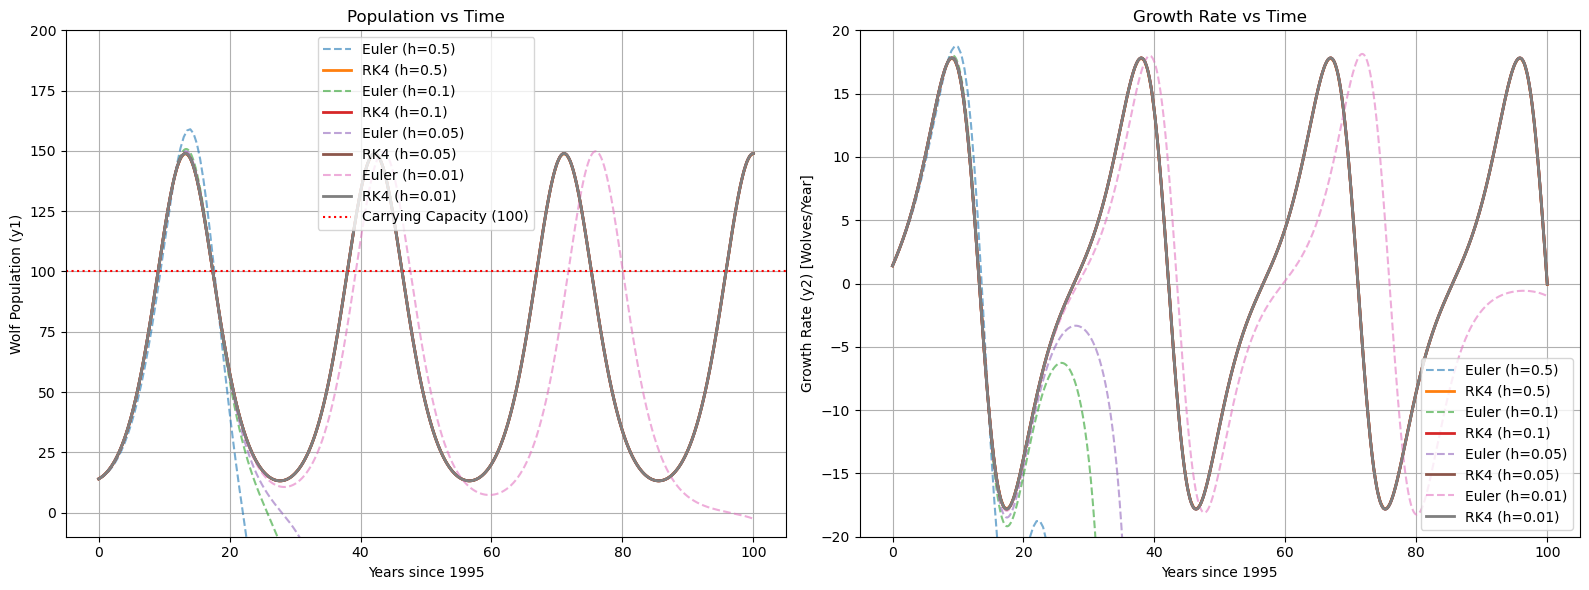

In [6]:
import matplotlib.pyplot as plt
#Parameters from your Section 2 research
params = (0.10, 0.001)  # r and k
initial_conditions = [14, 1.4]  # P(0) and dP/dt(0)
t_start, t_end = 0, 100 # Modeling 100 years post reintroduction

#Simulations with different step sizes
h_values = [0.5, 0.1, 0.05, 0.01] #step sizes to be tested

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for h in h_values:
    #solve using euler's method
    t_e, y_e = euler_method(wolf_dynamics, initial_conditions, t_start, t_end, h, args=params)
    #solve using RK4
    t_rk, y_rk = runge_kutta_4(wolf_dynamics, initial_conditions, t_start, t_end, h, args=params)

    #Plot 1: Population (y1) vs Time
    ax1.plot(t_e, y_e[:, 0], '--', label=f"Euler (h={h})", alpha=0.6)
    ax1.plot(t_rk, y_rk[:, 0], label=f"RK4 (h={h})", linewidth=2)

    #Plot 2: Growth Rate (y2) vs Time
    ax2.plot(t_e, y_e[:, 1], '--', label=f"Euler (h={h})", alpha=0.6)
    ax2.plot(t_rk, y_rk[:, 1], label=f"RK4 (h={h})", linewidth=2)

# Formatting the Population Plot
ax1.axhline(100, color='red', linestyle=':', label="Carrying Capacity (100)")
ax1.set_ylim(-10, 200)
ax1.set_xlabel("Years since 1995")
ax1.set_ylabel("Wolf Population (y1)")
ax1.set_title("Population vs Time")
ax1.legend()
ax1.grid(True)

# Formatting the Growth Rate Plot
ax2.set_ylim(-20, 20) # Adjust based on your expected growth rates
ax2.set_xlabel("Years since 1995")
ax2.set_ylabel("Growth Rate (y2) [Wolves/Year]")
ax2.set_title("Growth Rate vs Time")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

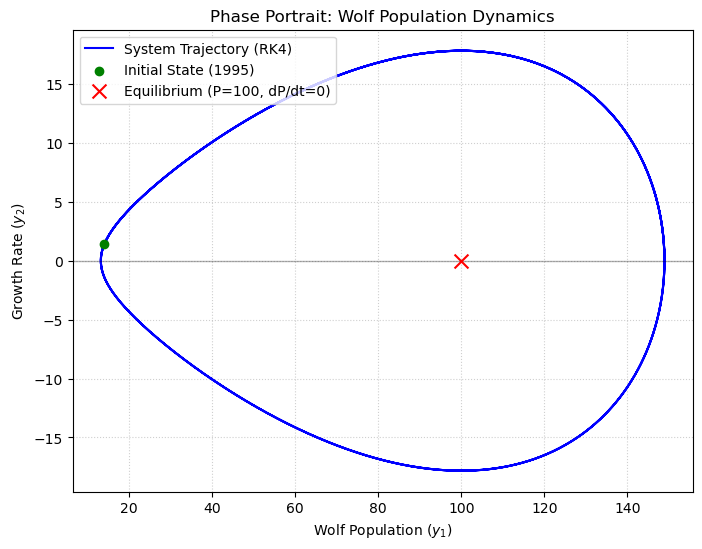

In [8]:
# Using the most accurate RK4 run (smallest h) for the phase portrait
h_stable = 0.01
t_ph, y_ph = runge_kutta_4(wolf_dynamics, initial_conditions, t_start, t_end, h_stable, args=params)

plt.figure(figsize=(8, 6))

# Plot the trajectory
plt.plot(y_ph[:, 0], y_ph[:, 1], color='blue', label='System Trajectory (RK4)')

# Mark the start and the equilibrium point
plt.scatter(y_ph[0, 0], y_ph[0, 1], color='green', zorder=5, label='Initial State (1995)')
plt.scatter(100, 0, color='red', marker='x', s=100, zorder=5, label='Equilibrium (P=100, dP/dt=0)')

# Formatting
plt.xlabel('Wolf Population ($y_1$)')
plt.ylabel('Growth Rate ($y_2$)')
plt.title('Phase Portrait: Wolf Population Dynamics')
plt.axhline(0, color='black', lw=1, alpha=0.3) # Zero growth line
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.show()

# Section 4: Solutions and Comparison
RK4 smoothly follows the population trend, with exact overlap throught the different step sizes. Euler's method follows well for smaller step sizes, but loses the line after the first oscillation through the carrying capacity. For the phase portrait, the plot starts at (14,1.4). As it travels right (increasing population), the growth rate decreases and begins to drop as population approaches the carrying capacity. The trajectory spirals around the point (100,0), which is the carrying capacity where $P=100$ and $\frac{dP}{dt}=0$.

/tmp/ipykernel_3426/2660756529.py:5: RuntimeWarning: overflow encountered in scalar power
  dy2_dt = r * y1 - k * y1**2


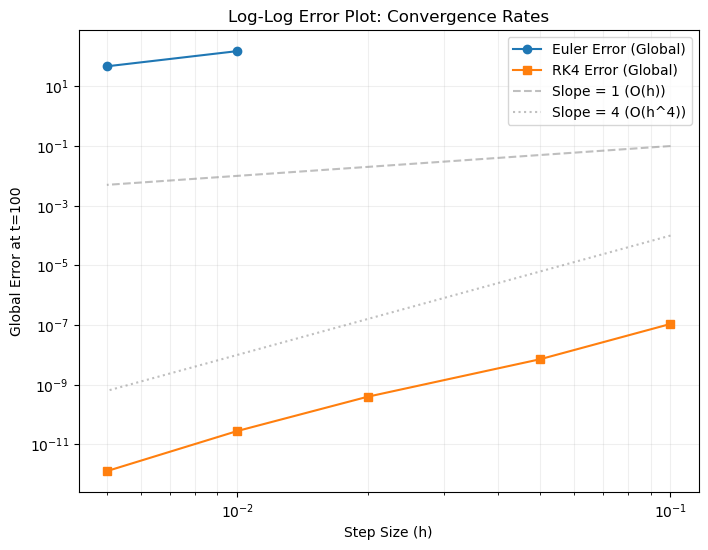

In [3]:
# Use the smallest possible step size as a reference
h_ref = 0.001
t_ref, y_ref = runge_kutta_4(wolf_dynamics, initial_conditions, t_start, t_end, h_ref, args=params)

# We only care about the Population (y1) at the final time point (tf)
true_final_pop = y_ref[-1, 0]

h_test_values = [0.1, 0.05, 0.02, 0.01, 0.005]
euler_errors = []
rk4_errors = []

for h in h_test_values:
    # Euler Error
    _, y_e = euler_method(wolf_dynamics, initial_conditions, t_start, t_end, h, args=params)
    euler_errors.append(abs(y_e[-1, 0] - true_final_pop))
    
    # RK4 Error
    _, y_rk = runge_kutta_4(wolf_dynamics, initial_conditions, t_start, t_end, h, args=params)
    rk4_errors.append(abs(y_rk[-1, 0] - true_final_pop))

# Create the Log-Log Plot
plt.figure(figsize=(8, 6))
plt.loglog(h_test_values, euler_errors, 'o-', label='Euler Error (Global)')
plt.loglog(h_test_values, rk4_errors, 's-', label='RK4 Error (Global)')

# Add theoretical slope lines for reference (Optional but looks great for the rubric)
plt.loglog(h_test_values, [h for h in h_test_values], '--', color='gray', alpha=0.5, label='Slope = 1 (O(h))')
plt.loglog(h_test_values, [h**4 for h in h_test_values], ':', color='gray', alpha=0.5, label='Slope = 4 (O(h^4))')

plt.xlabel('Step Size (h)')
plt.ylabel('Global Error at t=100')
plt.title('Log-Log Error Plot: Convergence Rates')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# Section 5: Stability Analysis
Euler's method is unstable even at $h=0.05$, only being stable at small step sizes such as $h=0.01$ wheras RK4 remains stable even at larger values like $h=1$, though with higher error. This is shown by only two points showing for euler's method, as anything larger results in an overflow error and cannot be calculated. Euler's method follows the slope $y=1$ reflecting it being a first order method $O(h)$, wheras RK4 follows the slope $y=4$ reflecting it is a fourth order method $O(h^4)$. When $h$ is greater than $h_{max}$ the "acceleration" ($y_2$) is too large and pushes the population ($y_1$) into a feedback loop. This leads to non-physical results, such as the population hitting $10^{300}$ or dipping into the negatives, something clearly impossible in real life.

# Section 6: Conclusion
RK4 performed much better for this application, as it does not "blow up" like euler's method. This is worth the additional computational cost because it is capable of tracking the wolf population for longer, through the first oscillation. You can also compensate for the higher computational cost that comes from the 4th order method by increasing the step size, using fewer iterations since RK4 is still stable at higher step sizes. I would reccomend using a higher order method as it tracks better and the error size decreases much faster than a first order method like euler. To match the accuracy of RK4, euler would require a step size so small it is impractical. I may also reccomend using an adaptive step size for long term applications such as this one.